# Simulación de Monte Carlo
En este notebook implementaremos diversas simulaciones de Monte Carlo utilizando diferentes modelos.

## Movimiento Browniano Geométrico (GBM)
El modelo más sencillo que consideraremos es el movimiento browniano geométrico o GBM. Este modelo se define por la ecuación diferencial estocástica siguiente:
$$dS_t = S_t \mu dt +  S_t \sigma dB_t.$$

Discretizando esta expresión para tiempos $t_0, t_1, ..., t_N$, obtenimos la relación recursiva
$$ S_{t_{k+1}} = S_{t_k} + S_{t_k} \mu \Delta t + S_{t_{k}} \sigma \sqrt{\Delta t} Z,$$
dónde $ Z \sim N(0,1)$.

Más adelante ajustaremos los parámetros del modelo a un conjunto de datos, pero de momento realizamos una simulación con parámetros ad hoc.

In [2]:
import SimulacionMonteCarlo 
import importlib
importlib.reload(SimulacionMonteCarlo)

<module 'SimulacionMonteCarlo' from '/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py'>

In [3]:
param_dict={'Deltat': 0.1, 'N':1000, 'mu':0.1, 'sigma':0.2, 'S0':1, 'M':1000}
gbm = SimulacionMonteCarlo.GBM(param_dict)
gbm.mostrar_parametros()

===== Parámetros del modelo =====
Deltat:		0.1
N:		1000
mu:		0.1
sigma:		0.2
S0:		1
M:		1000
T:		100.0


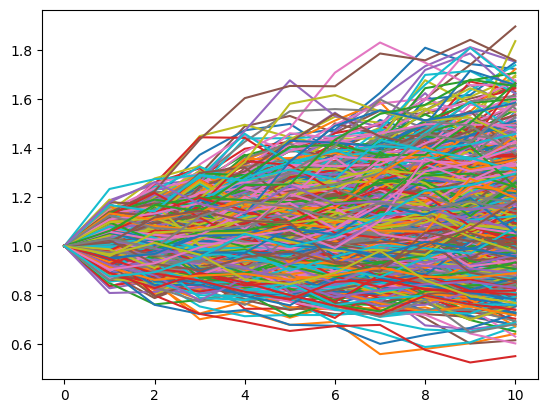

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(gbm.simular(N=10)).plot(legend=False)
plt.show()

### Ajuste de parámetros por máxima verosimilitud
Con tal de generar simulaciones más realistas, introducimos un método de ajuste de parámetros. El método ```ajustar_parametros``` tomará como entrada una serie temporal y el número de simulaciones que queremos hacer posteriormente. 

El método de ajuste de los parámetros se basa en la propiedad de Márkov de la serie temporal y en la función de verosimilitud de esa misma serie. La propiedad de Márkov consiste en, enunciada brevemente, que la última variable aleatoria de la serie contiene toda la información de las variables anteriores, por lo que condicionar a esta última variable es equivalente a condicionar a todas las anteriores. Es decir, si $A$ es un subconjunto (Borel mesurable) de $\mathbb{R}$, entonces
$$ P(S_{t_{n+1}} \in A | S_{t_n}, ..., S_{t_0}) = P(S_{t_{n+1}} \in A | S_{t_n}).$$

Esta propiedad nos resulta importante en nuestro contexto porque nos permite escribir la función de verosimilitud de una forma tratable analíticamente. En nuestro caso, la función de verosimilitud es de la forma $f(\mu, \sigma; \textbf{S})$. Tomamos logarítmos sobre esta y aplicamos la propiedad de Márkov para obtener
$$l(\mu, \sigma; \textbf{S}) = \sum_{k=1}^N l(\mu, \sigma; S_{t_k}| S_{t_{k-1}},...,S_{t_0}) = \sum_{k=1}^N l(\mu, \sigma; S_{t_k}| S_{t_{k-1}}).$$

Finalmente, para obtener la función explícita de la verosimilitud, solo hace falta observar la función recursiva de $S_{t_{k+1}}$ en términos de $S_{t_k}$, con lo que se obtiene que
$$ S_{t_{k+1}}|S_{t_k} \sim N( S_{t_k}(1+\mu \Delta t), \sigma^2\Delta t S_{t_k}^2).$$

In [5]:
import datos
importlib.reload(datos)
ts = datos.download_stock_data('AAPL')
ts = ts['close']

In [6]:
importlib.reload(SimulacionMonteCarlo)
gbm2 = SimulacionMonteCarlo.GBM()
gbm2.ajustar_parametros(ts, 1000)

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_params = {'T': ts.shape[0], 'N': ts.shape[0], 'Deltat':1., 'S0':ts[0], 'M':M}
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:133: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  -(ts[k]-ts[k-1]*(1+var_mu*new_params['Deltat']))**2/
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:134: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treat

Ajuste de parámetros realizado correctamente.


/home/jordi/.local/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: xlabel='date'>

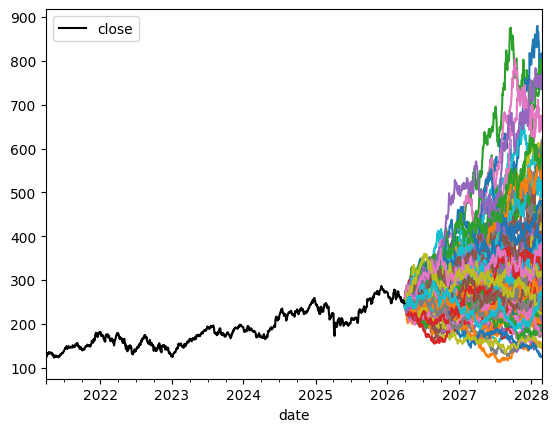

In [7]:
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
importlib.reload(SimulacionMonteCarlo)

sim = gbm2.simular(N=500, S0=ts.values[-1], M=100)
df_sim = pd.DataFrame(sim)
df_sim.index = datos.next_k_bdays(start=ts.index[-1], k=500)

fig, ax = plt.subplots(1,1)
ax.set_xlim(ts.index[0], df_sim.index[-1])
df_sim.plot(legend=False, ax=ax)
ts.plot(color='black', ax=ax, legend=True)

En el gráfico se puede observar aunque haya cierta varianza en la simulación (no olvidemos que se trata de un modelo probabilístico), las simulaciones se distribuyen entorno a nuestro juego de datos, confirmandonos por lo tanto que el ajuste ha sido efectuado correctamente.

## Modelo Merton Jump-Diffusion
Ahora añadimos a nuestro modelo la capacidad de simular saltos en el valor del activo. Esto lo hacemos añadiendo un nuevo sumando a la ecuación recursiva discretizada:
$$ S_{n+1}= S_n + \mu S_n \Delta t + \sigma S_n \sqrt{\Delta t} Z + J_n,$$
donde $J_n$ es una variable aleatoria que recoge la posibilidad y magnitud de un salto. Esta variable aleatoria depende de otra variable, llamadas $N_n$. Esta variable recoge el número de saltos en el intervalo $[t, t+ \Delta t)$.

La relación entre $J_n$ y $N_n$ es la siguiente: 

$$ J_n | N_n = k \sim N(k\mu_J, k^2\sigma_J^2), $$

y además imponemos que $N_n\sim $Poisson($\lambda$). Por lo tanto, este modelo tiene parámetros a ajustar $\mu, \sigma, \lambda, \mu_J$ y $\sigma_J$.



In [16]:
import SimulacionMonteCarlo 
import importlib
importlib.reload(SimulacionMonteCarlo)

<module 'SimulacionMonteCarlo' from '/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py'>

In [17]:
param_dict={'Deltat': 0.1, 'N':1000, 'mu':0, 'sigma':0.2, 'S0':200, 'M':10,
            'lambda': 0.05, 'mu_J':-10, 'sigma_J':250 } 
mjd = SimulacionMonteCarlo.MertonJumpDiffusion(param_dict)
mjd.informar_parametros(param_dict)
mjd.mostrar_parametros()

===== Parámetros del modelo =====
Deltat:		0.1
N:		1000
mu:		0
sigma:		0.2
S0:		200
M:		10
lambda:		0.05
mu_J:		-10
sigma_J:	250
T:		100.0


<Axes: >

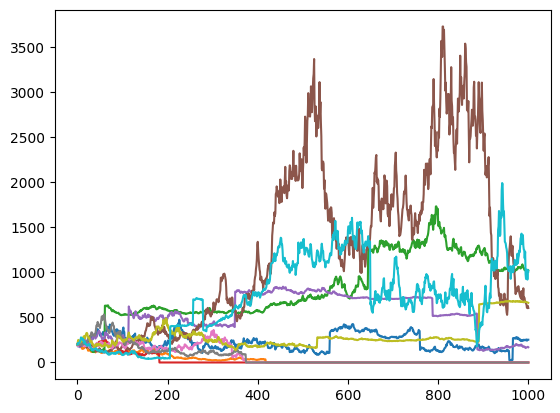

In [18]:
pd.DataFrame(mjd.simular()).plot(legend=False)

### Ajuste de parámetros
Con el objetivo de realizar el ajuste de los parámetros a los datos, vamos a formalizar lo que hemos descrito anteriormente sobre el modelo Merton Jump Diffusion. Lo que hemos dicho, en realidad, es que

$$ S_n | S_{n-1}, N_{n-1} = k \sim N(S_{n-1}(1+\mu\Delta t) + k\mu_J, S_{n-1}^2\Delta t\sigma^2 + k\sigma_J^2),$$
$$ N_{n-1} \sim \text{Poisson}(\lambda \Delta t).$$

A partir de aquí, podemos obtener la distribución de verosimilitud de la siguiente manera. Sea $\Theta$ el vector de todos los parámetros. Entonces, a partir de la expresión anterior para la verosimilitud, tenemos
$$l(\Theta; \textbf{S}) =\sum_{n=1}^N l(\Theta; S_n|S_{n-1}) = \sum_{n=1}^N \log \left( \sum_{k=0}^\infty \phi(S_n|S_{n-1}, N_{n-1} = k;\Theta) \cdot P (N_{n-1} = k; \lambda)\right),$$
donde $\phi$ es la función de densidad de la variable en cuestión.
En la práctica, consideraremos que el número máximo de saltos en cualquier intervalo de tiempo $\Delta t$ es 30 (no $\infty$). 

In [37]:
import SimulacionMonteCarlo 
import importlib
importlib.reload(SimulacionMonteCarlo)

<module 'SimulacionMonteCarlo' from '/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py'>

In [41]:
import datos
importlib.reload(datos)
ts = datos.download_stock_data('AAPL')
ts_jump = ts['close'].copy().values
ts = ts['close'].values
ts_jump[40:] += 200
ts_jump[300:] -= 100


In [42]:
mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(ts_jump, 100)
mjd.mostrar_parametros()

===== Parámetros del modelo =====
T:		1254
N:		1254
Deltat:		1.0
S0:		123.0
M:		100
mu:		0.0003359407803370673
sigma:		0.010191064119642152
lambda:		0.0033151313094857905
mu_J:		49.99998177946382
sigma_J:	49.892038370263606


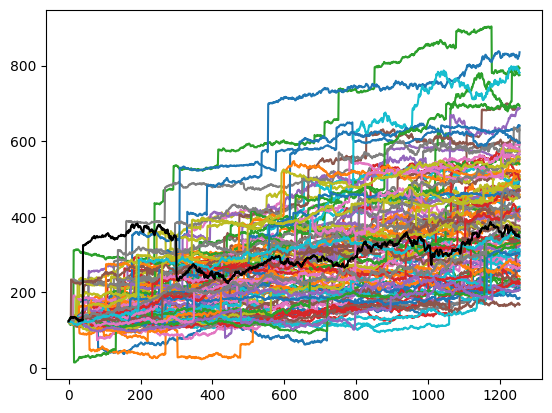

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(mjd.simular()).plot(legend=False)
plt.plot(ts_jump, color='black')

NOTA: Al final, hemos conseguido realizar la optimización con el algorítmo con utilizando el logarítmo de los parámetros que son estrictamente positivos, y utilizando el algorítmo L-BFGS-B, por lo que lo que sigue queda descontextualizado. Lo manetenemos a modo de documentación de lo que se ha intentado.

Observamos que el ajuste genera modelos degenerados si hay uno o pocos saltos.

#### Ajuste de modelos sin saltos
Al ajustar sobre un juego de datos sin saltos, se observa un comportamiento coherente pero peligroso: $\lambda$ se acerca a cero pero la varianza de la magnitud de los saltos, $\sigma_J$ explota. Con esto, no se producen saltos ya que la probabilidad de que ocurran es negligible, pero si llegaran a ocurrir, estos serian completamente no realistas. Como conclusión, debemos ajustar el modelo solo con datos con saltos.

===== Parámetros del modelo =====
T:		1254
N:		1254
Deltat:		1.0
S0:		123.0
M:		100
mu:		0.0005552108475065244
sigma:		0.017223760992005267
lambda:		1.2258135193353615e-08
mu_J:		50.0
sigma_J:	7.225973768125749e+86


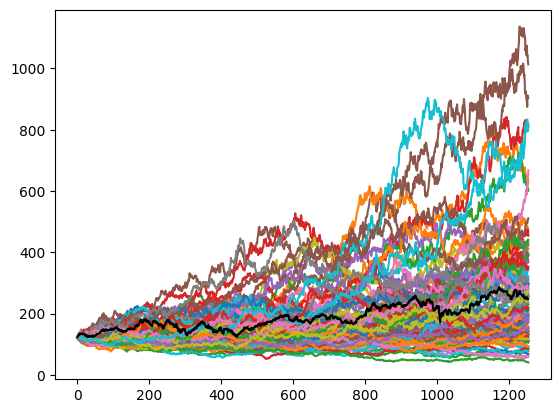

In [32]:
import datos
importlib.reload(datos)
ts = datos.download_stock_data('AAPL')
ts = ts['close'].values

mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(ts, 100)
mjd.mostrar_parametros()

import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(mjd.simular()).plot(legend=False)
plt.plot(ts, color='black')

#### Ajuste a modelos con un (o pocos) saltos

===== Parámetros del modelo =====
T:		1254
N:		1254
Deltat:		1.0
S0:		123.0
M:		100
mu:		0.0002554464458180282
sigma:		0.01312893787370369
lambda:		0.0024319478437962003
mu_J:		50.00000056753692
sigma_J:	49.695941545846885


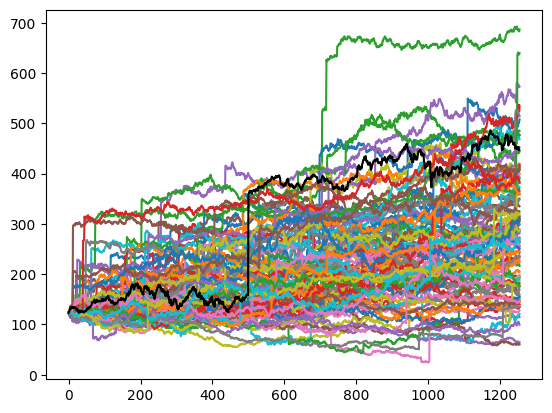

In [33]:
import datos
importlib.reload(datos)
ts = datos.download_stock_data('AAPL')
ts = ts['close'].values
ts_jump = ts
ts_jump[500:] += 200

mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(ts_jump, 100)
mjd.mostrar_parametros()

import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(mjd.simular()).plot(legend=False)
plt.plot(ts_jump, color='black')

### Cálculo del jacobiano
NOTA: Hemos probado con los métodos powell, y nelder-mead, pero no ha habido éxito en ninguno de los casos: en uno el proceso era extremadamente largo mientras que con el otro devolvía valores nulos. 

Probamos con métodos que utilizan el jacobiano de la función a optimizar. Para ello, lógicamente, debemos calcular el jacobiano de nuestra función de verosimilitud (cambiada de signo). 

Con el objetivo de calcular las derivadas de la función con respecto a los parámetros, definimos las variables intermedias siguientes:
$$M = S_{n-1}(1+\mu\Delta t) + k\mu_J, $$
$$\Sigma = \sqrt{S_{n-1}^2\Delta t\sigma^2 + k\sigma_J^2}.$$

De esta forma la derivada de $f(\Theta) = \phi(S_n|S_{n-1}, N_{n-1} = k;\Theta) \cdot P (N_{n-1} = k; \lambda)$ respecto cada parámetro es
$$ \frac{df}{d\Theta_i} = \frac{\partial f}{\partial M}\frac{\partial M}{\partial \Theta_i} + \frac{\partial f}{\partial \Sigma}\frac{\partial \Sigma}{\partial \Theta_i}.$$
Cada una de estas derivadas las calculamos con sympy.

De esta forma, nos queda que
$$\frac{\partial l}{\partial \Theta_i} = \sum_{n=1}^N \frac{\sum_{k=0}^\infty \frac{\partial f}{\partial \Theta_i}}{\sum_{k=0}^\infty f(\Theta)}$$

In [12]:
import sympy
def calcula_expresion_jacobiano():
    mu, sigma, lbda, mu_J, sigma_J = sympy.symbols('mu sigma lbda mu_J sigma_J')
    S_t, S_tm1, Deltat, k = sympy.symbols('S_t S_tm1 Deltat k')
    M_var, S_var = sympy.symbols('M_var S_var')
    
    M = S_tm1*(1+mu*Deltat) + k*mu_J
    S = sympy.sqrt((S_tm1*sigma)**2*Deltat + k*sigma_J**2)

    density_norm = 1/(sympy.sqrt(2*sympy.pi)*S_var)*sympy.exp(-(S_t-M_var)**2/(2*S_var**2))
    mass_poisson = sympy.exp(-lbda*Deltat)*(lbda*Deltat)**k/sympy.factorial(k)
    prob_function = density_norm*mass_poisson


    def sympy_2_numpy(expr):
        expr = str(expr)
        expr = expr.replace("sqrt", "np.sqrt")\
                   .replace("exp", "np.exp")\
                   .replace("factorial", "scipy.special.factorial")\
                   .replace("pi", "np.pi")\
                   .replace("M_var", "M")\
                   .replace("S_var", "Sigma")\
                   .replace("Deltat", "new_params[\'Deltat\']")\
                   .replace("S_tm1", "ts[n-1]")\
                   .replace("S_t", "ts[n]")
                   
        return expr
        
    for var in [mu, sigma, lbda, mu_J, sigma_J]:
        if var != lbda:
            derivative = prob_function.diff(M_var)*M.diff(var)
            derivative += prob_function.diff(S_var)*S.diff(var)
        else:
            derivative = prob_function.diff(lbda)
        expr = str(derivative)
        print(str(var) + ':')
        print(sympy_2_numpy(expr))
        print("\n")
        
    return 

calcula_expresion_jacobiano()

mu:
-np.sqrt(2)*new_params['Deltat']*ts[n-1]*(new_params['Deltat']*lbda)**k*(2*M - 2*ts[n])*np.exp(-new_params['Deltat']*lbda)*np.exp(-(-M + ts[n])**2/(2*Sigma**2))/(4*np.sqrt(np.pi)*Sigma**3*scipy.special.factorial(k))


sigma:
new_params['Deltat']*ts[n-1]**2*sigma*(-np.sqrt(2)*(new_params['Deltat']*lbda)**k*np.exp(-new_params['Deltat']*lbda)*np.exp(-(-M + ts[n])**2/(2*Sigma**2))/(2*np.sqrt(np.pi)*Sigma**2*scipy.special.factorial(k)) + np.sqrt(2)*(new_params['Deltat']*lbda)**k*(-M + ts[n])**2*np.exp(-new_params['Deltat']*lbda)*np.exp(-(-M + ts[n])**2/(2*Sigma**2))/(2*np.sqrt(np.pi)*Sigma**4*scipy.special.factorial(k)))/np.sqrt(new_params['Deltat']*ts[n-1]**2*sigma**2 + k*sigma_J**2)


lbda:
-np.sqrt(2)*new_params['Deltat']*(new_params['Deltat']*lbda)**k*np.exp(-new_params['Deltat']*lbda)*np.exp(-(-M + ts[n])**2/(2*Sigma**2))/(2*np.sqrt(np.pi)*Sigma*scipy.special.factorial(k)) + np.sqrt(2)*k*(new_params['Deltat']*lbda)**k*np.exp(-new_params['Deltat']*lbda)*np.exp(-(-M + ts[n])**2/(2*Si

### Algoritmo EM
Como último recurso, implementaremos el algoritmo EM para realizar la maximización de la función de verosimilitud. Este algoritmo consiste en definir una sucesión de parámetros $\Theta^{l}$ que converge al vector de parámetros óptimo des de nuestro punto de vista.

Como su nombre indica, este está compuesto por dos pasos, el primero el calculo de un valor esperado y el segundo un proceso de maximización. (En lo que sigue usaremos la desigualdad de Jensen).

\begin{align*}
l(\Theta) &= \sum_{n=1}^N\log \sum_{k=0}^\infty P(S_n|S_{n-1}, N_{n-1}=k; \Theta) \frac{q(z|\Theta)}{q(z|\Theta)}\\
&\geq \sum_{n=1}^N  \sum_{k=0}^\infty q(z|\Theta)\log(P(S_n|S_{n-1}, N_{n-1}=k; \Theta)) \\
&\quad - \sum_{n=1}^N  \sum_{k=0}^\infty q(z|\Theta)\log(q(z|\Theta))
\end{align*} 

En la expresión anterior podemos sustituir lo siguiente:
$$ P(S_n|S_{n-1}, N_{n-1}=k; \Theta)= \phi(S_n, M, \Sigma) \cdot P (N_{n-1} = k; \lambda).$$

El punto clave del algorítmo es escoger $q$: para que el algoritmo converja, debemos sustituir 
$$q(\Theta^{(l)}) = P(N_{n-1}=k|S_n, S_{n-1};\Theta^{(l)}) = \frac{P(S_n|S_{n-1}, N_{n-1}=k; \Theta^{(l)})P(N_{n-1}=k; \Theta^{(l)})}{\sum_{k'=0}^\infty P(S_n|S_{n-1}, N_{n-1}=k'; \Theta^{(l)})P(N_{n-1}=k'; \Theta^{(l)})}.$$

De esta forma, y nos hemos saltado detalles intermedios, tenemos la recurrencia
$$\Theta^{(l+1)} = {\arg\max}_{\Theta} \sum_{n=1}^N  \sum_{k=0}^\infty q(\Theta^{(l)})\log(P(S_n|S_{n-1}, N_{n-1}=k; \Theta))$$

In [695]:
import SimulacionMonteCarlo 
import importlib
importlib.reload(SimulacionMonteCarlo)

mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(ts_jump, 100)

Primera optimización...:
mu:		2.6479063148787674e-06
sigma:		1.0016621808692865
lambda:		0.999203040649686
mu_J:		0.9986223875108295
sigma_J:	1.0

mu:		-0.2138582725801412
sigma:		0.7866688919707463
lambda:		0.8906546170809891
mu_J:		0.9983281529951642
sigma_J:	0.9999991228131807



/home/jordi/.local/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2076: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:304: RuntimeWarning: divide by zero encountered in log
  ksum += q*np.log(argument_log)
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:304: RuntimeWarning: invalid value encountered in scalar multiply
  ksum += q*np.log(argument_log)


ERROR: EM: no se ha podido optimizar en el paso M.


### Algorítmo EM, solución analítica
Habiendo fracasado en implementar la solución automática (por no convergencia de los algoritmos), pasamos a buscar soluciones analíticas al problema de maximización del algoritmo EM. Primeramente definimos los pesos del paso $l$ como

$$w_{nk}^{(l)} = \frac{\phi(S_n|S_{n-1}, N_{n-1} = k;\Theta^{(l)}) e^{-\lambda^{(l)} \Delta t}\frac{(\lambda^{(l)} \Delta t)^k}{k!} }{\sum_{k'=0}^\infty \phi(S_n|S_{n-1}, N_{n-1} = k';\Theta^{(l)}) e^{-\lambda^{(l)} \Delta t}\frac{(\lambda^{(l)} \Delta t)^{k'}}{k'!}}.$$

Entonces la expresión que debemos maximizar es

\begin{align*}
\sum_{n=1}^N \sum_{k=0}^\infty & w_{nk}^{(l)} \log (\phi(S_n, M, \Sigma) \cdot P (N_{n-1} = k; \lambda)) \\
&= \sum_{n=1}^N \sum_{k=0}^\infty w_{nk}^{(l)}\left(-\log(\sqrt{2\pi}\Sigma) - \frac{(S_n-M)^2}{2\Sigma^2} -\lambda \Delta t + k\log(\lambda \Delta t)- \log(k!)\right).
\end{align*}

Las soluciones son las siguientes, definimos $\bar{k}_n = \sum_{k=0}^{k_{\max}} w_{nk} \, k$ y $x_n = \log(S_n / S_{n-1})$, entonces

\begin{align*}
    \lambda^{(l+1)} &= \frac{\sum_{n=1}^N \bar{k}_n}{N \, \Delta t}\\
    \mu_0^{(l+1)} &= \frac{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \left( x_n - k \, \mu_J^{(l+1)} \right)}{N \, \Delta t}\\
    \mu_J^{(l+1)} &= \frac{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \, k \left( x_n - \mu_0^{(l+1)} \Delta t \right)}{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \, k^2}\\
    \left(\sigma_J^2\right)^{(l+1)} &= \frac{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \, k \left( x_n - \mu_0^{(l+1)} \Delta t - k \, \mu_J^{(l+1)} \right)^2}{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \, k^2}\\
    \left(\sigma^2\right)^{(l+1)} &= \frac{\sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \left( x_n - \mu_0^{(l+1)} \Delta t - k \, \mu_J^{(l+1)} \right)^2 - \left(\sigma_J^2\right)^{(l+1)} \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} \, k}{N \, \Delta t}\\
    \bar{k}^{(l+1)} &= e^{\mu_J^{(l+1)} + \frac{1}{2}\left(\sigma_J^2\right)^{(l+1)}} - 1 \\
    \mu^{(l+1)} &= \mu_0^{(l+1)} + \frac{\left(\sigma^2\right)^{(l+1)}}{2} + \lambda^{(l+1)} \, \bar{k}^{(l+1)}
\end{align*}

Observamos que las ecuaciones para $\mu_0^{(l+1)}$ y $\mu_J^{(l+1)}$ forman un sistema de ecuaciones lineal:
\begin{align}
    A &= \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk} = N \\
    B &= \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk}\, k \\
    C &= \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk}\, k^2 \\
    D &= \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk}\, x_n \\
    E &= \sum_{n=1}^N \sum_{k=0}^{K_{\max}} w_{nk}\, k\, x_n
\end{align}

El paso de maximización involucra un sistema de ecuaciones lineal $2\times 2$:
\begin{align}
    \begin{pmatrix} A & B \\ B & C \end{pmatrix}
    \begin{pmatrix} \mu_0^{(l+1)} \Delta t \\ \mu_J^{(l+1)} \end{pmatrix}
    =
    \begin{pmatrix} D \\ E \end{pmatrix}
\end{align}

con solución:
\begin{align}
    \mu_0^{(l+1)} &= \frac{C D - B E}{(AC - B^2)\,\Delta t} \\[6pt]
    \mu_J^{(l+1)} &= \frac{A E - B D}{A C - B^2}
\end{align}

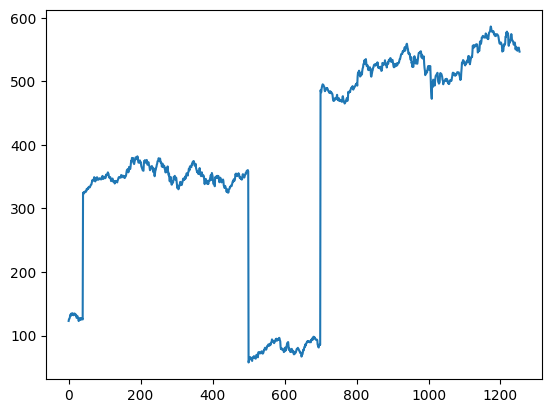

In [25]:
import SimulacionMonteCarlo 
import importlib

import datos
importlib.reload(datos)
ts = datos.download_stock_data('AAPL')
ts_jump = ts['close'].values
ts_jump[40:] += 200
ts_jump[500:] -= 300
ts_jump[700:] += 400
plt.plot(ts_jump)

In [26]:
%%time
importlib.reload(SimulacionMonteCarlo)

mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(ts_jump, 10)
mjd.mostrar_parametros()

===== Parámetros del modelo =====
T:		1254
N:		1254
Deltat:		1.0
S0:		123.0
M:		10
mu:		0.0006271530827031061
sigma:		0.011357668357062537
lambda:		0.00951292003822044
mu_J:		50.000226309866825
sigma_J:	50.00029590792596
CPU times: user 8.14 s, sys: 12.4 ms, total: 8.16 s
Wall time: 1.34 s


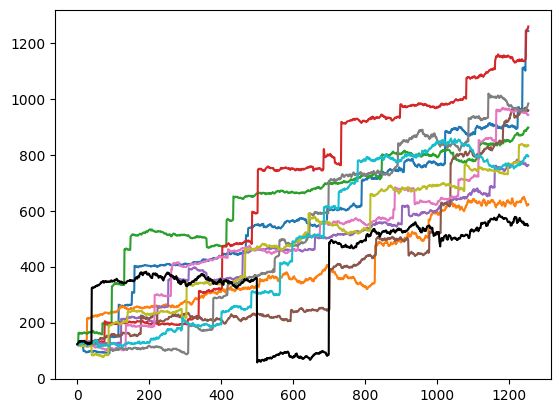

In [27]:
pd.DataFrame(mjd.simular()).plot(legend=False)
plt.plot(ts_jump,color='black')

**La vectorización de la función de verosimilitud se ha hecho con IA, explicar esta vectorización**